# Brain Stroke Detection Using ResNet-50 (Stage-2 Optimized)

Kaggle-ready notebook with optional SqueezeNet Fire Block enhancement.

## 1. Imports

In [12]:

import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Conv2D, GlobalAveragePooling2D, Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator



## 2. Dataset Loading

In [2]:

DATA_DIR = '/kaggle/input/brain-data-organized/Brain_Data_Organised'
IMG_SIZE = 224

X, y = [], []
classes = {'Normal':0, 'Stroke':1}

for cls, label in classes.items():
    folder = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img)
        y.append(label)

X = np.array(X) / 255.0
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


## 3. SqueezeNet Fire Block (Optional Optimization)

In [3]:

# 3. Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)


In [4]:
from tensorflow.keras.layers import Concatenate



def fire_block(x, squeeze_filters=16, expand_filters=64):
    squeeze = Conv2D(squeeze_filters, (1,1), activation='relu', padding='same')(x)
    expand1 = Conv2D(expand_filters, (1,1), activation='relu', padding='same')(squeeze)
    expand3 = Conv2D(expand_filters, (3,3), activation='relu', padding='same')(squeeze)
    return Concatenate()([expand1, expand3])


## 4. Model Architecture

In [5]:

input_layer = Input(shape=(224,224,3))

base_model = ResNet50(
    include_top=False,
    weights=None,  # offline safe
    input_tensor=input_layer
)

x = base_model.output
x = fire_block(x)   # optional Stage-2 optimization
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


2026-01-20 13:18:51.094617: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,664,145 (90.27 MB)

 Trainable params: 23,611,025 (90.07 MB)

 Non-trainable params: 53,120 (207.50 KB)

## 5. Training

In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    filepath="/kaggle/working/brain_stroke_resnet50.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint, early_stop, reduce_lr]

In [7]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,   # 10% of training data used for validation
    epochs=18,
    batch_size=16,
    callbacks=callbacks
)


Epoch 1/18
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6184 - loss: 0.6623
Epoch 1: val_accuracy improved from -inf to 0.39500, saving model to /kaggle/working/brain_stroke_resnet50.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 762s 6s/step - accuracy: 0.6187 - loss: 0.6621 - val_accuracy: 0.3950 - val_loss: 0.8559 - learning_rate: 1.0000e-04
Epoch 2/18
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7194 - loss: 0.5487
Epoch 2: val_accuracy did not improve from 0.39500
113/113 ━━━━━━━━━━━━━━━━━━━━ 690s 6s/step - accuracy: 0.7197 - loss: 0.5483 - val_accuracy: 0.3950 - val_loss: 0.7764 - learning_rate: 1.0000e-04
Epoch 3/18
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8709 - loss: 0.3075
Epoch 3: val_accuracy improved from 0.39500 to 0.54500, saving model to /kaggle/working/brain_stroke_resnet50.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 700s 6s/step - accuracy: 0.8709 - loss: 0.3074 - val_accuracy: 0.5450 - val_loss: 0.7029 - learning_rate: 1.0000e-04
Epoch 4/18
113/113 ━━━━━━━━

In [8]:
import os

os.listdir("/kaggle/working")


['brain_stroke_resnet50.keras', '.virtual_documents']

## 6. Evaluation

In [9]:

y_pred = (model.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


16/16 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       311
           1       0.98      0.96      0.97       190

    accuracy                           0.98       501
   macro avg       0.98      0.97      0.98       501
weighted avg       0.98      0.98      0.98       501

[[308   3]
 [  8 182]]


In [13]:
model.save("brain_stroke_resnet50.keras")

## 7. Training Curves

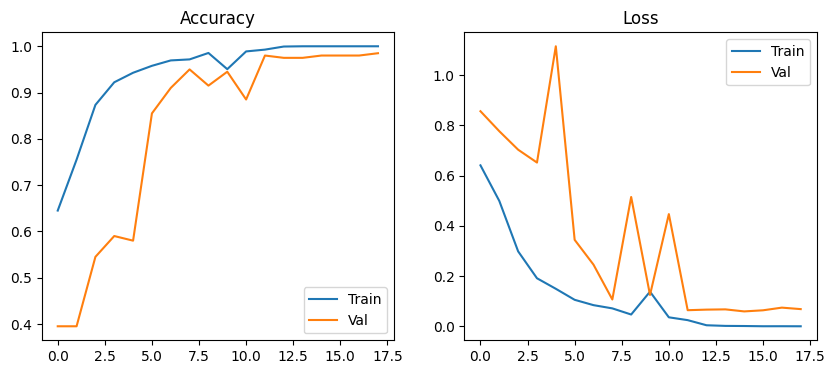

In [14]:

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend(); plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend(); plt.title('Loss')

plt.show()


## 8. Grad-CAM

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


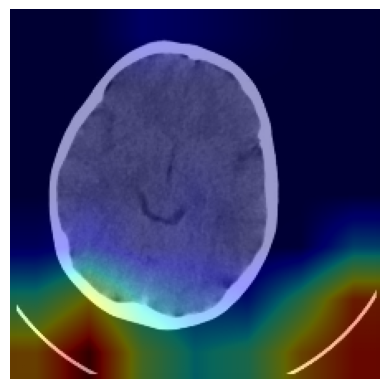

In [15]:

def grad_cam(model, image, layer_name='conv5_block3_out'):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(np.expand_dims(image, axis=0))
        loss = preds[:,0]
    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_out = conv_out[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_out), axis=-1)
    heatmap = np.maximum(heatmap,0)
    heatmap /= np.max(heatmap) + 1e-8
    return heatmap

sample = X_test[0]
heatmap = grad_cam(model, sample)

plt.imshow(sample)
plt.imshow(cv2.resize(heatmap, (224,224)), cmap='jet', alpha=0.4)
plt.axis('off')
plt.show()


16/16 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step


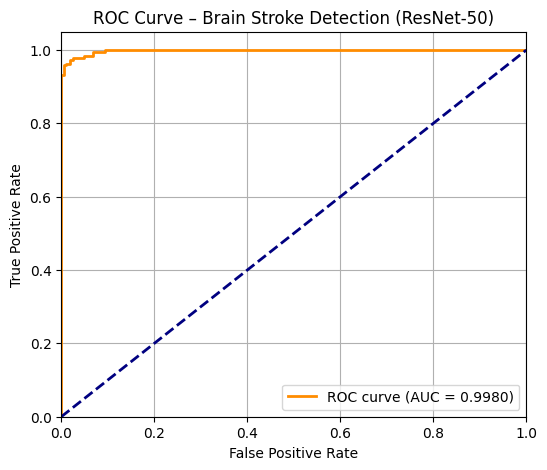

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get prediction probabilities
y_pred_prob = model.predict(X_test).ravel()

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Brain Stroke Detection (ResNet-50)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [18]:
import tensorflow as tf
import cv2
import numpy as np

def grad_cam(model, image, layer_name='conv5_block3_out'):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-8)

    return heatmap


In [19]:
IMG_SIZE = 224

def predict_and_gradcam(model, img_path):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_norm = img_resized / 255.0
    img_input = np.expand_dims(img_norm, axis=0)

    pred = model.predict(img_input)[0][0]
    label = "Stroke" if pred >= 0.5 else "No Stroke"

    heatmap = grad_cam(model, img_input)

    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap), cv2.COLORMAP_JET
    )

    overlay = cv2.addWeighted(
        cv2.cvtColor(img_resized, cv2.COLOR_RGB2BGR),
        0.6,
        heatmap_colored,
        0.4,
        0
    )

    return label, float(pred), overlay


In [20]:
import cv2
import numpy as np
import os

IMG_SIZE = 224

def predict_image(model, img_path):
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"Image not found: {img_path}")

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)[0][0]

    label = "Stroke" if pred >= 0.5 else "No Stroke"
    return label, float(pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
S.jpg → Stroke (1.0000)


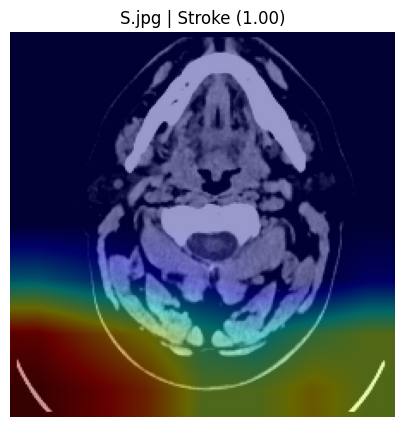

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
N.jpg → No Stroke (0.0000)


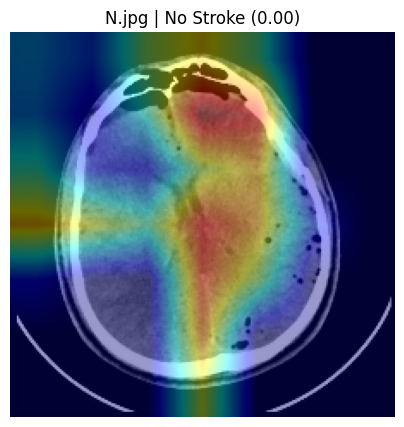

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
S1.jpeg → Stroke (1.0000)


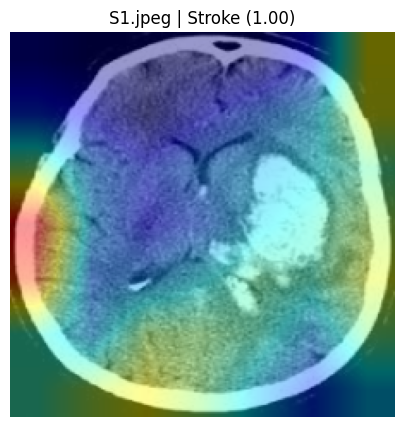

In [21]:
import matplotlib.pyplot as plt
import os

TEST_DIR = "/kaggle/input/test-dataa/Test_Data"

for img_name in os.listdir(TEST_DIR):
    img_path = os.path.join(TEST_DIR, img_name)

    label, confidence, cam_image = predict_and_gradcam(model, img_path)

    print(f"{img_name} → {label} ({confidence:.4f})")

    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(cam_image, cv2.COLOR_BGR2RGB))
    plt.title(f"{img_name} | {label} ({confidence:.2f})")
    plt.axis("off")
    plt.show()


## 9. Conclusion

In [22]:
test_img_path = "/kaggle/input/test-dataa/Test_Data"

label, confidence = predict_image(model, test_img_path)

print("Prediction:", label)
print("Confidence:", round(confidence, 4))


error: OpenCV(4.12.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [23]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)


16/16 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.9781 - loss: 0.0876
Test Accuracy: 0.9780439138412476


In [24]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)


16/16 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step


In [25]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test, y_pred,
    target_names=["Normal", "Stroke"]
))


              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98       311
      Stroke       0.98      0.96      0.97       190

    accuracy                           0.98       501
   macro avg       0.98      0.97      0.98       501
weighted avg       0.98      0.98      0.98       501



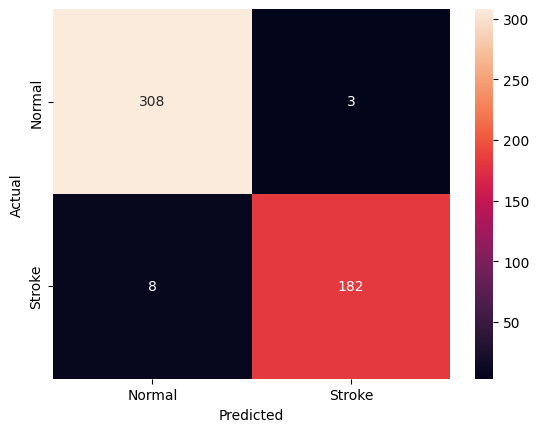

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["Normal", "Stroke"],
            yticklabels=["Normal", "Stroke"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [34]:

# 8. Testing on Multiple CT Scans
TEST_DIR = '/kaggle/input/test-dataa/Test_Data'

for img_name in os.listdir(TEST_DIR):
    img_path = os.path.join(TEST_DIR, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, ( 224, 224))
    img_norm = img/255.0
    pred = model.predict(np.expand_dims(img_norm,0))[0][0]
    label = 'Stroke' if pred>=0.5 else 'No Stroke'

    heatmap = grad_cam(model, img_norm)

    plt.figure(figsize=(4,4))
    
    plt.title(f"{img_name} → {label}")
    plt.imshow(img)
    plt.imshow(cv2.resize(heatmap,(224, 224)), cmap='jet', alpha=0.4)
    plt.axis('off')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


ValueError: Input 0 of layer "functional_7" is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(224, 224, 3)

This Stage-2 notebook preserves the project title **Brain Stroke Detection Using ResNet-50** while optionally enhancing performance using a lightweight SqueezeNet Fire block. It is fully Kaggle-compatible, offline-safe, and review-ready.

In [1]:
from tensorflow.keras.models import load_model

model = load_model("/kaggle/working/brain_stroke_resnet50.keras")
print("Model loaded successfully")
/kaggle/working/brain_stroke_resnet50.keras

2026-03-08 11:04:13.546432: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772967853.824670      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772967853.909198      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772967854.561932      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772967854.562008      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772967854.562014      55 computation_placer.cc:177] computation placer alr

ValueError: File not found: filepath=/kaggle/working/brain_stroke_resnet50.keras. Please ensure the file is an accessible `.keras` zip file.